# Engineered-break experiment — three SFH variants

Fit galaxy 42580 (worst nearby cont-only, z=0.019, data Dn4000≈2.29) under three SFH choices,
all with logzsol free (full grid) and dust/smoothing/norm optimized, gas+SFH-hyperparams fixed:

1. **SFH fixed, Σ(logsfr_ratios) = −10.8** (−1.2 ×9)
2. **SFH fixed, Σ = −14.4** (−1.6 ×9, more extreme old)
3. **wide / free SFH** (logsfr_ratios free, wide StudentT prior, started old)

Reference (free-SFH MAP, stochastic prior) is loaded from the KC13 pkl. Results are **saved**
to `results/engineered_break_3sfh_<TID>.pkl` and the comparison plot to `results/`.
Run from repo root in the FSPS/Cue env.

In [1]:
import os, sys, pickle, warnings
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'bin', 'prospector'))
import numpy as np
import matplotlib.pyplot as plt
from prospect.fitting import lnprobfn
from prospect.models.sedmodel import SpecModel, HyperSpecModel
from prospect.models.priors import Uniform, StudentT
import parameter_file as P
import fit_config as FC
import map_chi2 as M
from scipy.signal import medfilt

WAVE_OBS = np.asarray(P.WAVE_OBS); C_AA = 2.99792458e18
def dn4000(flam, z):
    wr = WAVE_OBS/(1+z); fnu = flam*wr**2/C_AA
    b=(wr>=3850)&(wr<=3950); r=(wr>=4000)&(wr<=4100)
    if b.sum()<3 or r.sum()<3: return np.nan
    return (np.trapezoid(fnu[r],wr[r])/np.ptp(wr[r]))/(np.trapezoid(fnu[b],wr[b])/np.ptp(wr[b]))

/Users/ng27753/Astronomy_Research/hubersed/.venv/lib/python3.13/site-packages/prospect/sources/fake_fsps.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
# ---- config ----
REF_PKL  = '../results/map_chi2_cue_outliers_lsf_KC13dust_full.pkl'   # free-SFH MAP (KC13) reference
TARGETID = 39633140817331167   # idx 42580, z~0.019
SAVE_PKL = '../results/engineered_break_3sfh_%d.pkl' % TARGETID
SAVE_PNG = '../results/engineered_3sfh_%d.png' % TARGETID

In [3]:
# ---- reference (free-SFH MAP) from pkl ----
D = pickle.load(open(REF_PKL,'rb'))
ref = next(r for r in D['results'] if int(r['id'])==TARGETID and r.get('status')=='ok')
z=ref['z']; flux=np.asarray(ref['flux']); unc=np.asarray(ref['unc']); mask=np.asarray(ref['mask'])
model_ref=np.asarray(ref['model']); td=ref['theta_dict']
data_dn4000 = dn4000(flux, z)
print(f"reference free-SFH MAP: chi2_red={ref['chi2_red']:.2f}  Dn4000={dn4000(model_ref,z):.2f}  | data Dn4000={data_dn4000:.2f}")

reference free-SFH MAP: chi2_red=10.95  Dn4000=1.58  | data Dn4000=2.29


In [4]:
# ---- engineered fit: fixed or free SFH; logzsol free; dust/smoothing/norm optimized ----
def engineered_fit3(old_lr, free_sfh, logzsol_init=0.12, maxfev=8000):
    M._fsps()  # patch SSPBasis.spectral_resolution=0 so the DESI LSF passes
    obs = P.build_obs(spec=flux, unc=unc, mask=mask, resolution=M._lsf_sigma_kms())
    cmodel, ctemplate = FC.build_continuum_model(z)
    fmodel, ft = FC.build_full_cue_model(ctemplate, cmodel.theta.copy(), cmodel, z)
    ft['logsfr_ratios']['init'] = np.asarray(old_lr, float)
    if free_sfh:
        ft['logsfr_ratios']['isfree'] = True
        ft['logsfr_ratios']['prior'] = StudentT(mean=np.zeros(9), scale=np.full(9,2.0), df=np.full(9,2))
    else:
        ft['logsfr_ratios']['isfree'] = False
    ft['logzsol']['isfree'] = True; ft['logzsol']['init'] = float(logzsol_init)
    ft['logzsol']['prior'] = Uniform(mini=-2.5, maxi=0.5)
    for k in ['sigma_reg','tau_eq','tau_in','sigma_dyn','tau_dyn']:
        if k in ft: ft[k]['isfree'] = False
    ft['logmass']['init'] = float(np.atleast_1d(td['logmass'])[0])
    fmodel = SpecModel(ft)
    sps_n = M._cue()
    def neg(th):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                lp = lnprobfn(th, model=fmodel, observations=obs, sps=sps_n, nested=False)
                return -lp if np.isfinite(lp) else 1e18
            except Exception:
                return 1e18
    idx_z = fmodel.theta_index['logzsol']
    best = None
    for z0 in [0.0, 0.3]:                       # logzsol multi-start
        th = fmodel.theta.copy(); th[idx_z] = z0
        if neg(th) >= 1e17: th = fmodel.theta.copy()
        bf = M._map_optimize(neg, th, n_seeds=3, maxfev=maxfev)
        if bf is not None and (best is None or bf.fun < best.fun): best = bf
    theta = best.x
    preds, _ = fmodel.predict(theta, observations=obs, sps=sps_n)
    sp = np.asarray(preds[0]); mm = obs[0].mask
    resid = (obs[0].flux[mm] - sp[mm]) / obs[0].uncertainty[mm]
    chi2 = float(np.nansum(resid**2)); ndof = int(mm.sum()) - len(theta)
    theta_dict = {k: np.asarray(theta[v], float) for k, v in fmodel.theta_index.items()}
    return dict(model=sp, chi2_red=chi2/ndof, dn4000=dn4000(sp, z),
                logzsol=float(theta[idx_z]), theta=np.asarray(theta, float),
                labels=list(fmodel.free_params), theta_dict=theta_dict,
                old_lr=np.asarray(old_lr, float), free_sfh=bool(free_sfh))

In [5]:
# ---- run the three + SAVE ----
configs = [
    ("Sigma=-10.8 (fixed)", np.full(9,-1.2), False),
    ("Sigma=-14.4 (fixed)", np.full(9,-1.6), False),
    ("wide free SFH",        np.full(9,-1.2), True),
]
fits = {}
for nm, lr, free in configs:
    fits[nm] = engineered_fit3(lr, free)
    f = fits[nm]
    print(f"{nm:22s} chi2_red={f['chi2_red']:.2f}  Dn4000={f['dn4000']:.2f}  logzsol={f['logzsol']:+.2f}")

with open(SAVE_PKL, 'wb') as fh:
    pickle.dump(dict(wave=WAVE_OBS.astype(np.float32), z=z, targetid=TARGETID,
                     flux=flux, unc=unc, mask=mask, model_ref=model_ref,
                     ref_chi2_red=ref['chi2_red'], data_dn4000=data_dn4000, fits=fits), fh)
print("saved ->", SAVE_PKL)

Loading calibrated DESI resolution from resolution matrices...


/var/folders/4v/k4xpjdyx3f1_c95lc_dlyhkr0000gq/T/ipykernel_30051/1742307152.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  logzsol=float(theta[idx_z]), theta=np.asarray(theta, float),


Sigma=-10.8 (fixed)    chi2_red=4.67  Dn4000=2.21  logzsol=+0.09


/var/folders/4v/k4xpjdyx3f1_c95lc_dlyhkr0000gq/T/ipykernel_30051/1742307152.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  logzsol=float(theta[idx_z]), theta=np.asarray(theta, float),


Sigma=-14.4 (fixed)    chi2_red=4.66  Dn4000=2.23  logzsol=+0.11
wide free SFH          chi2_red=4.87  Dn4000=2.16  logzsol=-0.04
saved -> ../results/engineered_break_3sfh_39633140817331167.pkl


/var/folders/4v/k4xpjdyx3f1_c95lc_dlyhkr0000gq/T/ipykernel_30051/1742307152.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  logzsol=float(theta[idx_z]), theta=np.asarray(theta, float),


(3533.908203125, 9643.6435546875)

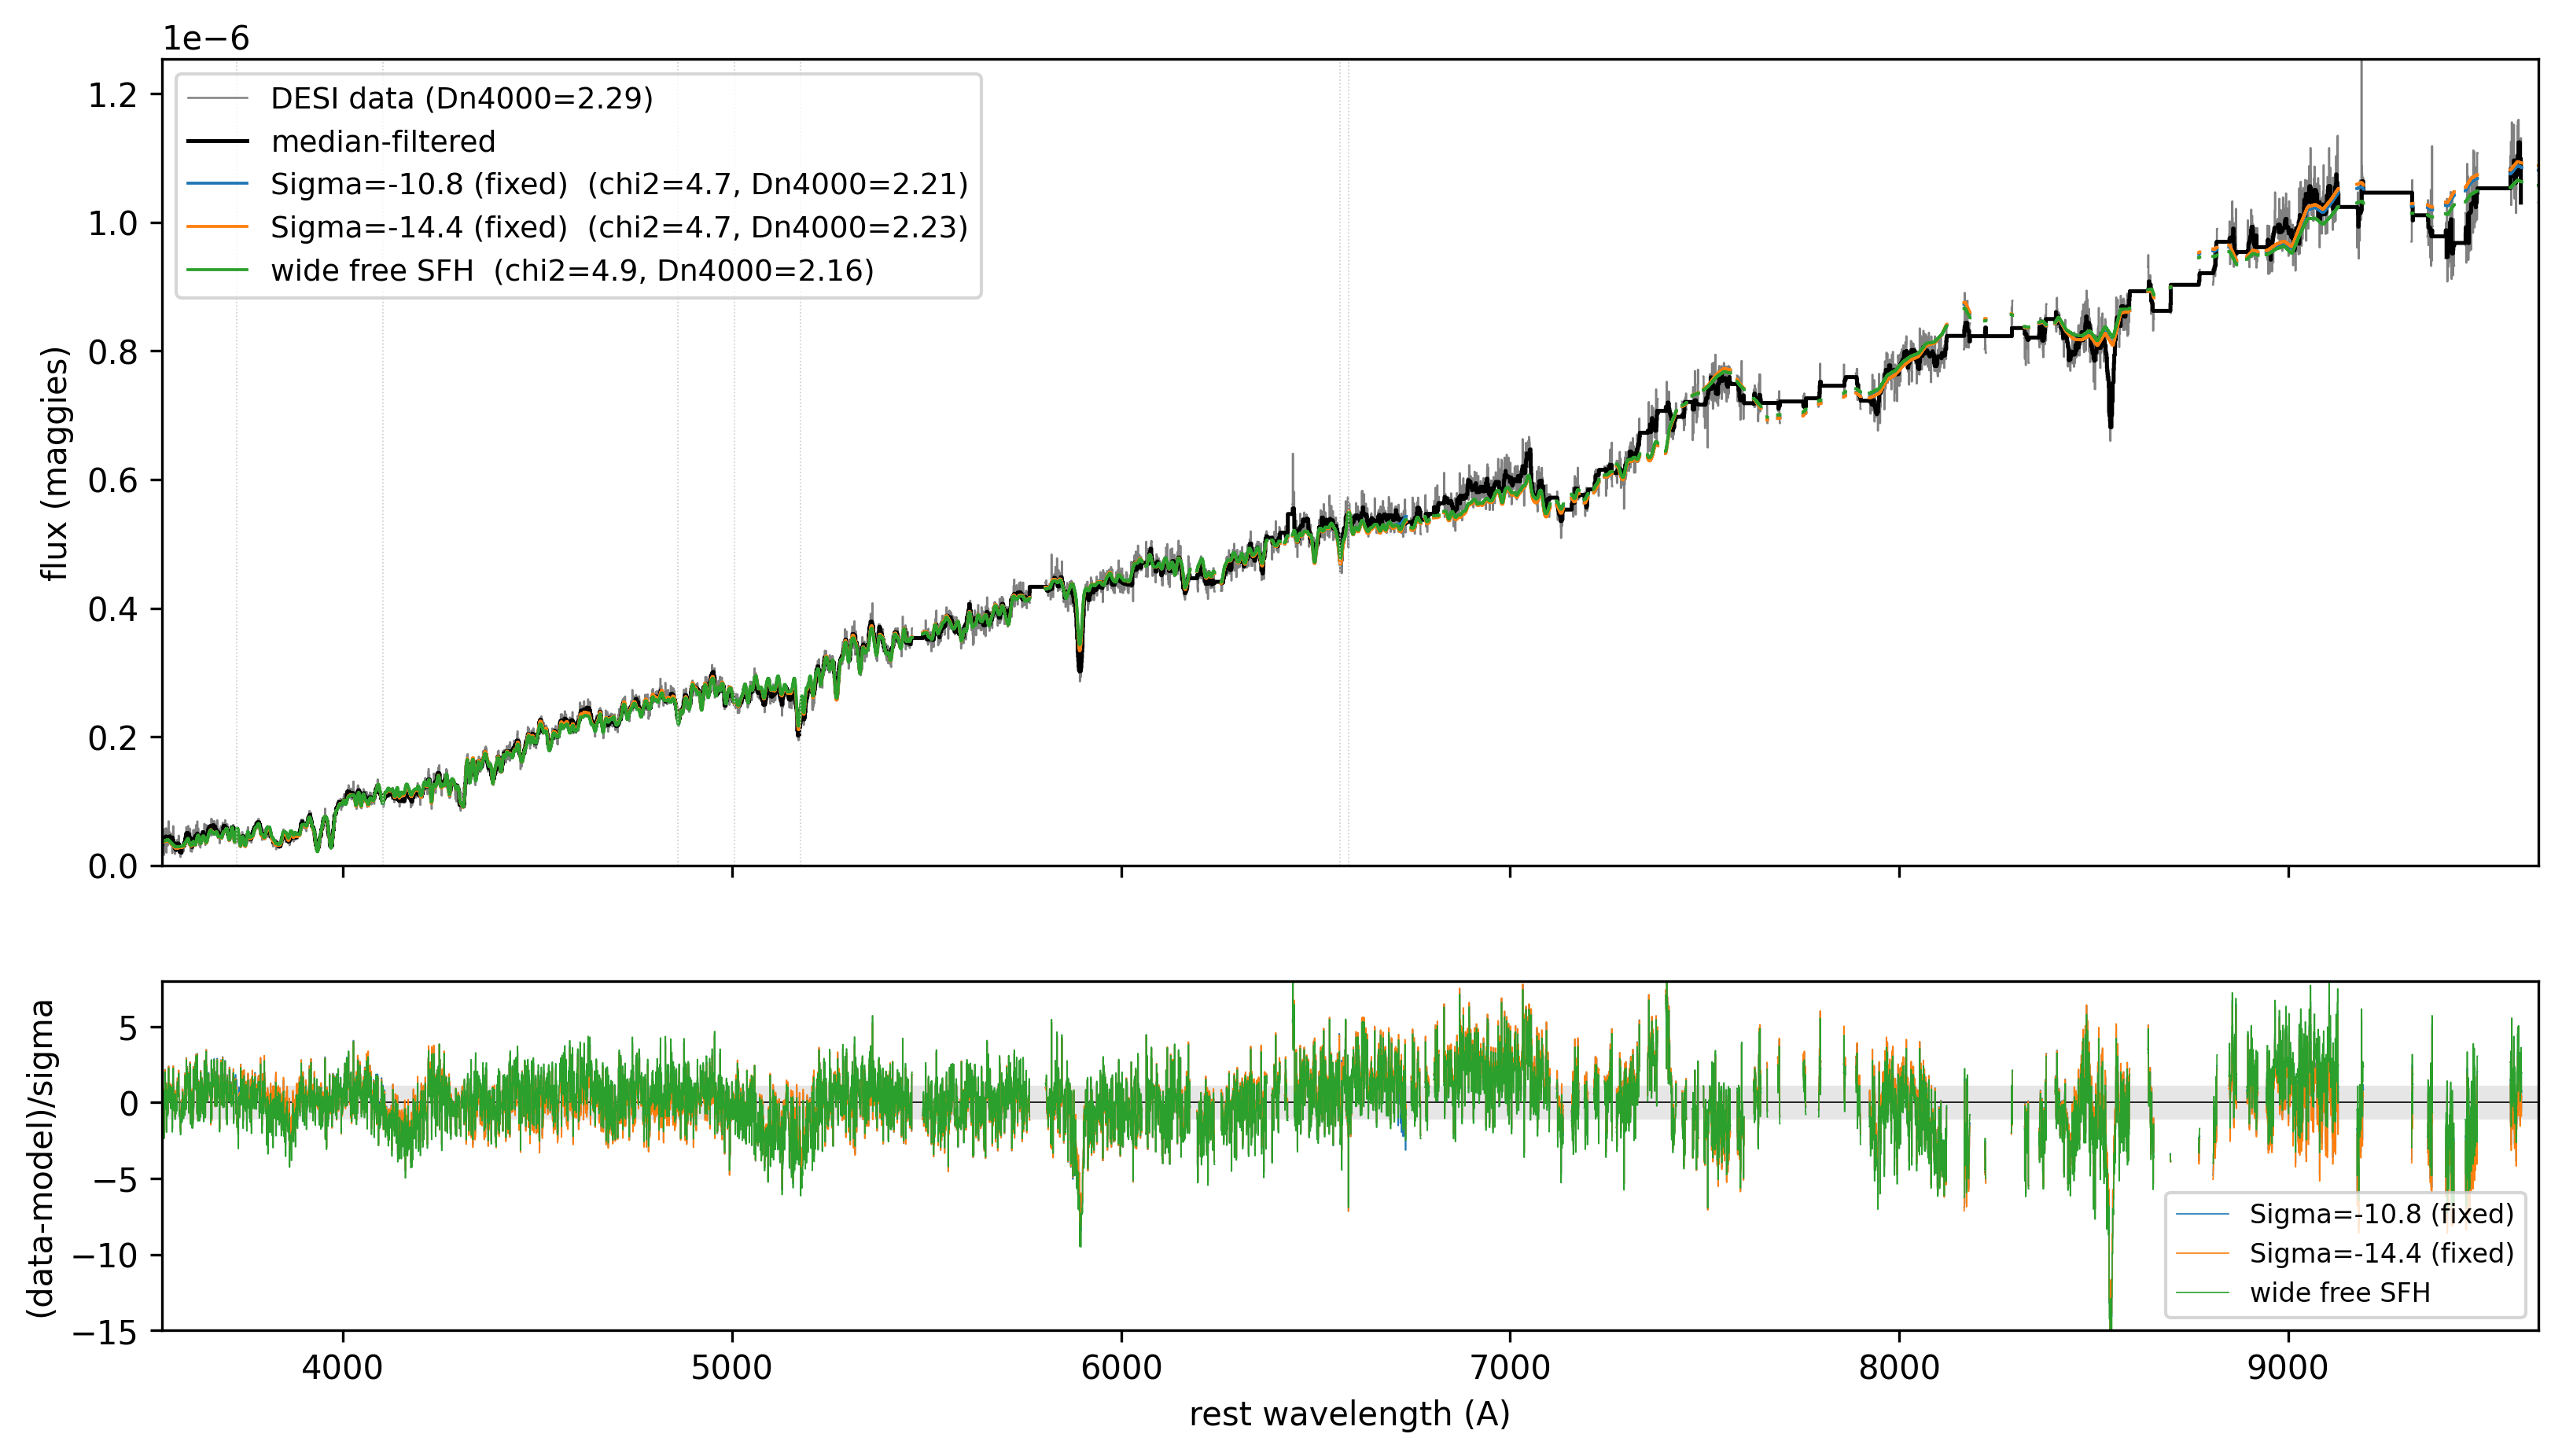

In [6]:
wr = WAVE_OBS/(1+z); mm = mask; ok = mm & (unc>0)
fl = flux.copy(); fl[~mm] = np.nan
colors = {"Sigma=-10.8 (fixed)":'C0', "Sigma=-14.4 (fixed)":'C1' , "wide free SFH":'C2'}
fig, (a, b) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios':[3,1.3]}, dpi=300)
a.step(wr, fl, lw=0.6, color='0.5', label=f'DESI data (Dn4000={data_dn4000:.2f})')
a.step(medfilt(wr[mm], 9), medfilt(fl[mm], 9), lw=1.2, color='k', label='median-filtered')
for nm in colors:
    f = fits[nm]; md_ = f['model'].copy(); md_[~mm] = np.nan
    a.step(wr, md_, lw=0.9, color=colors[nm], label=f"{nm}  (chi2={f['chi2_red']:.1f}, Dn4000={f['dn4000']:.2f})")
a.set_ylim(0, np.nanpercentile(fl,99.5)*1.15); a.set_ylabel('flux (maggies)'); a.legend(fontsize=9, loc='upper left')
for w0 in [3727,4102,4861,5007,5175,6563,6584]: a.axvline(w0, ls=':', color='0.8', lw=0.4)
b.axhspan(-1, 1, color='0.9'); b.axhline(0, color='k', lw=0.4)
for nm in colors:
    rr = np.full_like(flux, np.nan); rr[ok] = (flux[ok]-fits[nm]['model'][ok])/unc[ok]
    b.step(wr, rr, lw=0.4, color=colors[nm], label=nm)
b.set_ylim(-15, 8); b.set_xlabel('rest wavelength (A)'); b.set_ylabel('(data-model)/sigma'); b.legend(fontsize=8, loc='lower right')
b.set_xlim(np.nanmin(wr[mm]), np.nanmax(wr[mm]))
# fig.tight_layout(); fig.savefig(SAVE_PNG, dpi=140, bbox_inches='tight'); print("saved ->", SAVE_PNG); plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results/sfh_of_fits_39633140817331167.png'

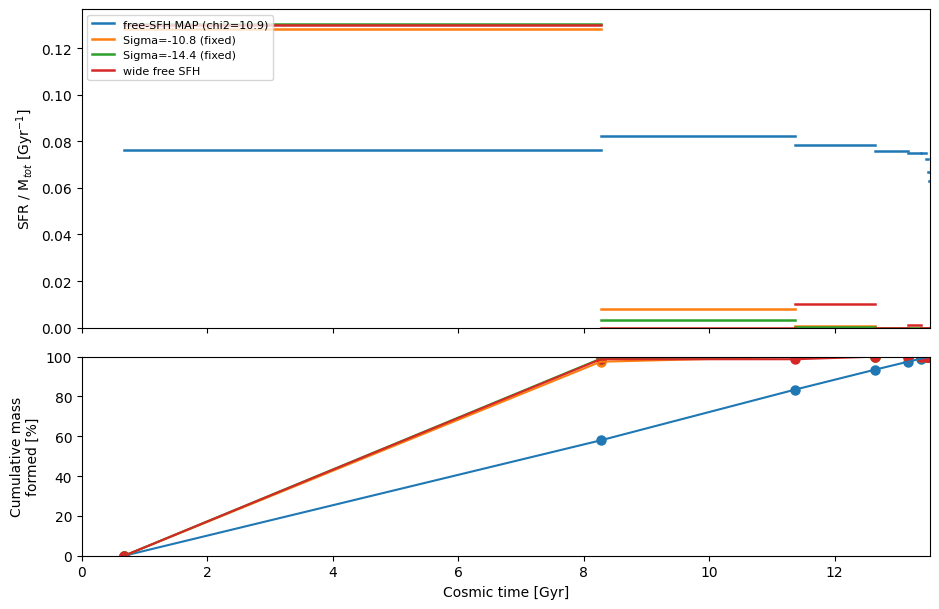

In [23]:
# --- SFHs of the fits, using Prospector's own SFH helpers ---
import numpy as np, pickle
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from prospect.plotting.sfh import ratios_to_sfrs, sfh_to_cmf, nonpar_mwa
from prospect.plotting.utils import step
from hubersed.prospector.utils import make_stochastic_agebins

S = pickle.load(open(SAVE_PKL, 'rb')); z = S['z']; t_obs = cosmo.age(z).to_value(u.Gyr)
ab = make_stochastic_agebins(z)          # log10(yr) — same agebins as the fit
ages = 10**(ab - 9)                       # lookback bin edges, Gyr

def lr_of(f):
    return f['old_lr'] if not f['free_sfh'] else np.atleast_1d(np.asarray(f['theta_dict']['logsfr_ratios'], float))

Dref = pickle.load(open(REF_PKL, 'rb'))
rr = next(x for x in Dref['results'] if int(x['id'])==S['targetid'] and x.get('status')=='ok')
curves = [(f"free-SFH MAP (chi2={rr['chi2_red']:.1f})",
           np.atleast_1d(np.asarray(rr['theta_dict']['logsfr_ratios'], float)), 'C0')]
for nm, c in [("Sigma=-10.8 (fixed)", 'C1'), ("Sigma=-14.4 (fixed)", 'C2'), ("wide free SFH", 'C3')]:
    f = S['fits'][nm]
    curves.append((f"{nm}", lr_of(f), c))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True, gridspec_kw={'height_ratios':[1.6,1]})
for nm, lr, c in curves:
    sfr  = ratios_to_sfrs(10.0, lr, ab)            # Msun/yr per bin
    ssfr = sfr / 10**10.0 * 1e9                     # SFR/Mtot, Gyr^-1 (logmass cancels)
    step(t_obs - ages[:, 1], t_obs - ages[:, 0], y=ssfr, ax=a1, color=c, label=nm, linewidth=1.8)
    cage, cmf = sfh_to_cmf(sfr, ab)                 # lookback edges (Gyr), cumulative mass formed
    a2.plot(t_obs - cage, cmf * 100, color=c, lw=1.5)
    a2.scatter(t_obs - cage, cmf * 100, color=c, lw=1.5)
a1.set_ylabel('SFR / M$_{tot}$ [Gyr$^{-1}$]'); a1.set_ylim(0, None); a1.legend(fontsize=8, loc='upper left')
a2.set_ylabel('Cumulative mass\nformed [%]'); a2.set_xlabel('Cosmic time [Gyr]')
a2.set_xlim(0, t_obs); a2.set_ylim(0, 100)
fig.tight_layout(); fig.savefig('results/sfh_of_fits_%d.png' % S['targetid'], dpi=140, bbox_inches='tight'); plt.show()

continuum-only: TID 39633140817331167  status=ok  chi2_red=7.96
emission-line-only: TID 39632991244258619  status=ok  chi2_red=22.46


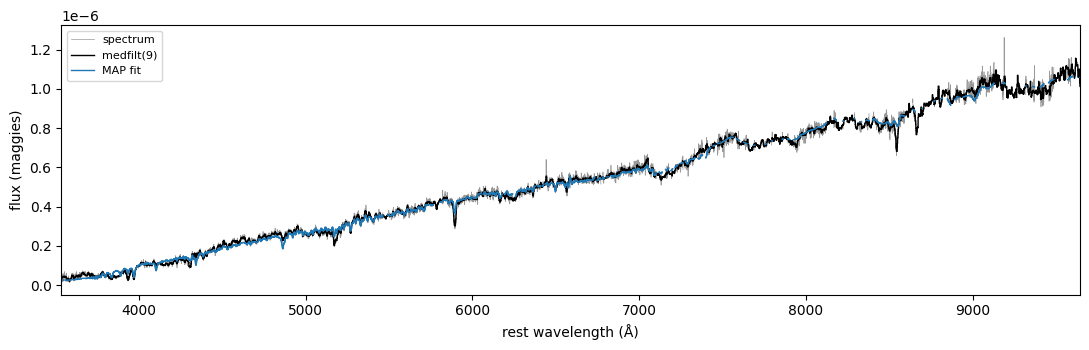

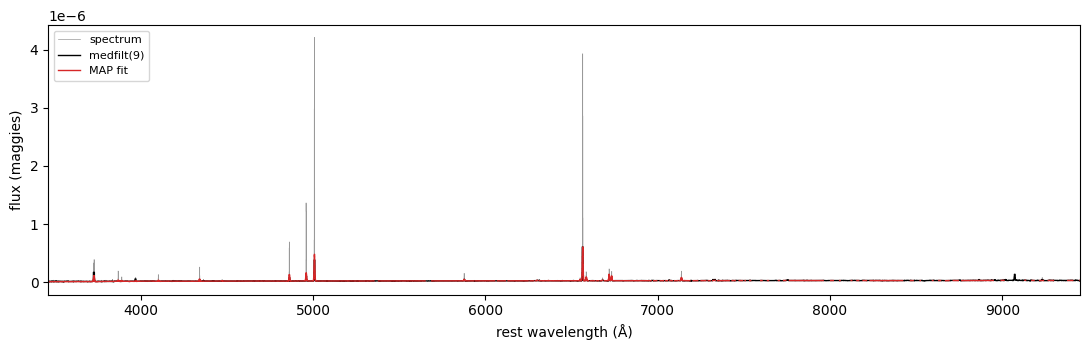

In [37]:
import sys, pickle, numpy as np
sys.path.insert(0, '../bin/prospector')                 # run from repo root
from scipy.signal import medfilt
import matplotlib.pyplot as plt
import map_chi2 as M

wave = np.asarray(M.WAVE_OBS)
cases = {'continuum-only': (39633140817331167, 'C0'),
         'emission-line-only': (39632991244258619, 'C3')}
out = {}
for nm, (tid, c) in cases.items():
    gidx = int(M.tids_to_indices(np.array([tid]))[0])
    r = M.map_chi2_one(gidx, use_cue=True)             # cheap-budget Cue MAP fit
    out[nm] = r
    print(f"{nm}: TID {tid}  status={r.get('status')}  chi2_red={r.get('chi2_red', np.nan):.2f}")
pickle.dump({'wave': wave, 'results': out}, open('../results/mapfit_cont_line_examples.pkl', 'wb'))

for nm, (tid, c) in cases.items():
    r = out[nm]
    if r.get('status') != 'ok':
        print(nm, 'skipped:', r.get('status')); continue
    z = r['z']; wr = wave/(1+z); m = np.asarray(r['mask'])
    flux = np.asarray(r['flux']); model = np.asarray(r['model'])
    fl = flux.copy(); fl[~m] = np.nan; md = model.copy(); md[~m] = np.nan
    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.step(wr, fl, where='mid', lw=0.5, color='0.6', label='spectrum')
    ax.step(wr, medfilt(flux, 9), where='mid', lw=1.0, color='k', label='medfilt(9)')
    ax.step(wr, md, where='mid', lw=1.0, color=c, label='MAP fit')
    ax.set_xlabel('rest wavelength (Å)'); ax.set_ylabel('flux (maggies)')
    ax.set_xlim(wr.min(), wr.max()); ax.legend(fontsize=8, loc='upper left')
    fig.tight_layout()
    fig.savefig('../results/mapfit_%s_%d.png' % (nm.replace('-', '').replace(' ', ''), tid),
                dpi=140, bbox_inches='tight'); plt.show()